# Offshore Wind LCOE Calculator

**Algorithmic LCOE (Levelized Cost of Energy) Calculation for European Offshore Wind Farms**

Based on `wind_dataset.csv` data.

**Modules:**
1. **CAPEX** (inflation adjustment and grid connection model)
2. **Energy Yield** (CF from data or estimation by wind_speed)
3. **OPEX** (base + adjustment by distance and foundation type)
4. **LCOE** (discounting, CRF)
5. **Validation and sensitivity analysis**
6. **Project map** (Folium)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries downloaded.")

Libraries downloaded.


## 1. Data loading

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_CANDIDATES = (
    Path('input') / 'wind_dataset.csv',
    Path('output') / 'wind_dataset.csv',
    Path('wind_dataset.csv'),
)
DATASET_PATH = next((candidate for candidate in DATASET_CANDIDATES if candidate.is_file()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(f'Dataset not found. Checked: {DATASET_CANDIDATES}')

df = pd.read_csv(DATASET_PATH)

print(f'Dataset path: {DATASET_PATH}')
print(f'Dataset size: {df.shape[0]} projects, {df.shape[1]} features')

key_cols = ['wind_farm_name', 'country', 'commissioning_year', 'installed_capacity_MW',
            'foundation_type', 'water_depth_m', 'distance_from_shore_km',
            'total_budget_EUR_2026', 'mean_hub_wind_speed', 'capacity_factor',
            'grid_connection_model', 'project_lifetime_years']
print(df[key_cols].dtypes)


Dataset path: input/wind_dataset.csv
Dataset size: 182 projects, 24 features
wind_farm_name                str
country                       str
commissioning_year        float64
installed_capacity_MW     float64
foundation_type               str
water_depth_m             float64
distance_from_shore_km    float64
total_budget_EUR_2026     float64
mean_hub_wind_speed       float64
capacity_factor               str
grid_connection_model         str
project_lifetime_years    float64
dtype: object


# 2. Data Preprocessing and Cleaning

In [3]:
df['capacity_factor'] = pd.to_numeric(df['capacity_factor'], errors='coerce')

df['project_lifetime_years'] = df['project_lifetime_years'].fillna(25.0)

floating_keywords = ['floating', 'spar', 'semi-submersible', 'tlp', 'damping', 'sath']
df['is_floating'] = df['foundation_type'].str.lower().str.contains(
    '|'.join(floating_keywords), na=False
)
df['foundation_category'] = df['is_floating'].map({True: 'Floating', False: 'Fixed'})

df_model = df[df['total_budget_EUR_2026'].notna() & df['installed_capacity_MW'].notna()].copy()

print(f"   Projects after filtering: {len(df_model)}")
print(f"   Floating: {df_model['is_floating'].sum()}, Fixed: {(~df_model['is_floating']).sum()}")
print(f"   Missing CF values: {df_model['capacity_factor'].isna().sum()}/{len(df_model)}")
print(f"   Missing lifetime values: {df_model['project_lifetime_years'].isna().sum()}")

   Projects after filtering: 176
   Floating: 14, Fixed: 162
   Missing CF values: 157/176
   Missing lifetime values: 0


## 3. CAPEX Module

   - `CAPEX_unit = total_budget_EUR_2026 / installed_capacity_MW` [EUR/MW]
   - **Adjustment for grid connection model:**
       - `TSO_provided` → Cables not included in budget → **+15% adjustment**
       - `Developer_included` → Cables already included in budget → No adjustment

In [5]:
def calculate_capex(row):
    base_capex = row['total_budget_EUR_2026']
    capacity = row['installed_capacity_MW']
    if capacity <= 0 or base_capex <= 0:
        return pd.Series({'CAPEX_total_EUR': np.nan, 'CAPEX_unit_EUR_per_MW': np.nan})
    
    cable_adder = 1.15 if row['grid_connection_model'] == 'TSO_provided' else 1.0
    total_capex = base_capex * cable_adder
    return pd.Series({
        'CAPEX_total_EUR': total_capex,
        'CAPEX_unit_EUR_per_MW': total_capex / capacity
    })

capex_cols = ['CAPEX_total_EUR', 'CAPEX_unit_EUR_per_MW']
df_model[capex_cols] = df_model.apply(calculate_capex, axis=1)

print("CAPEX calculated")
print(f"   Mean: {df_model['CAPEX_unit_EUR_per_MW'].mean()/1e6:.2f} million EUR/MW")
print(f"   Median: {df_model['CAPEX_unit_EUR_per_MW'].median()/1e6:.2f} million EUR/MW")

print("\nTop 10 countries by median CAPEX (million EUR/MW):")
print((df_model.groupby('country')['CAPEX_unit_EUR_per_MW']
       .median().sort_values(ascending=False) / 1e6).round(2).head(10).to_string())


CAPEX calculated
   Mean: 30.71 million EUR/MW
   Median: 4.93 million EUR/MW

Top 10 countries by median CAPEX (million EUR/MW):
country
Portugal    415.11
Finland      68.83
Sweden       43.21
Spain        19.82
Ireland      14.56
Italy        12.93
UK            5.17
Germany       5.16
France        4.84
Belgium       4.82


## 4. Energy Yield Module

   - `capacity_factor` = f(wind_speed) — if CF is missing, estimate it based on wind speed
   - `productivity_brutto` = 8760 * capacity_factor [hours/year]
   - `productivity_netto` = productivity_brutto * 0.85 (availability + electrical losses)
   - `annual_production_MWh` = productivity_netto * installed_capacity_MW

**CF regression on wind_speed (modern projects ≥ 2010):**
``
CF = 0.096 * wind_speed − 0.413
``
Clip the result to the range [0.25, 0.65].

Energy Yield calculated
   Mean Capacity Factor: 0.474
   Mean Annual Production: 2125 GWh/year


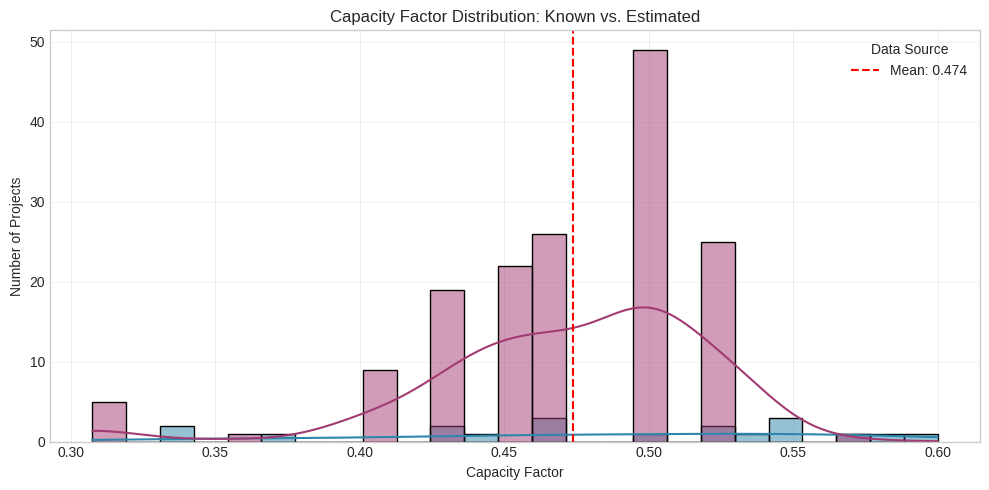

In [7]:
CF_SLOPE = 0.0960
CF_INTERCEPT = -0.4125

def estimate_capacity_factor(row):
    if pd.notna(row['capacity_factor']) and row['capacity_factor'] > 0:
        return row['capacity_factor']
    
    wind = row['mean_hub_wind_speed']
    if pd.isna(wind):
        return 0.40
    
    return np.clip(CF_SLOPE * wind + CF_INTERCEPT, 0.25, 0.65)


df_model['capacity_factor_est'] = df_model.apply(estimate_capacity_factor, axis=1)

df_model['capacity_factor_source'] = df_model['capacity_factor'].apply(
    lambda x: 'Known' if pd.notna(x) else 'Estimated'
)


HOURS_PER_YEAR = 8760
AVAILABILITY_FACTOR = 0.85

df_model['productivity_brutto_h'] = HOURS_PER_YEAR * df_model['capacity_factor_est']
df_model['productivity_netto_h'] = df_model['productivity_brutto_h'] * AVAILABILITY_FACTOR
df_model['annual_production_MWh'] = (
    df_model['productivity_netto_h'] * df_model['installed_capacity_MW']
)


print("Energy Yield calculated")
print(f"   Mean Capacity Factor: {df_model['capacity_factor_est'].mean():.3f}")
print(f"   Mean Annual Production: {df_model['annual_production_MWh'].mean()/1e3:.0f} GWh/year")


fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_model,
    x='capacity_factor_est',
    hue='capacity_factor_source',
    bins=25,
    kde=True,
    ax=ax,
    palette={'Known': '#2E86AB', 'Estimated': '#A23B72'}
)

ax.set_xlabel('Capacity Factor')
ax.set_ylabel('Number of Projects')
ax.set_title('Capacity Factor Distribution: Known vs. Estimated')
ax.axvline(
    df_model['capacity_factor_est'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Mean: {df_model['capacity_factor_est'].mean():.3f}"
)
ax.legend(title='Data Source')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. OPEX Module

- OPEX_base = 65 kEUR/MW/year (fixed), 85 kEUR/MW/year (floating)
- Distance adjustment:
  - ≤50 km: +5 kEUR/MW/year  
  - 50–100 km: +15 kEUR/MW/year  
  - >100 km: +25 kEUR/MW/year

OPEX calculated
   Mean: 74.4 kEUR/MW/year
   Range: 70 – 110 kEUR/MW/year


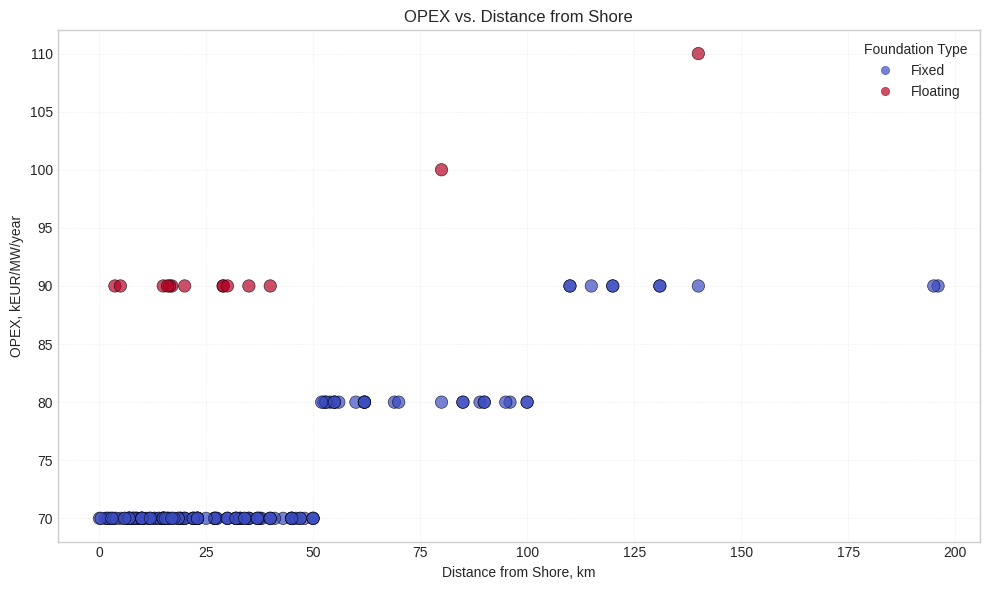

In [11]:
def calculate_opex(row):
    opex_base = 85.0 if row['is_floating'] else 65.0
    
    dist = row['distance_from_shore_km']
    if pd.isna(dist):
        dist_corr = 10.0
    elif dist <= 50:
        dist_corr = 5.0
    elif dist <= 100:
        dist_corr = 15.0
    else:
        dist_corr = 25.0
    
    return opex_base + dist_corr


df_model['OPEX_unit_kEUR_per_MW_year'] = df_model.apply(calculate_opex, axis=1)

df_model['annual_OPEX_total_EUR'] = (
    df_model['OPEX_unit_kEUR_per_MW_year'] * 1000 * df_model['installed_capacity_MW']
)


print("OPEX calculated")
print(f"   Mean: {df_model['OPEX_unit_kEUR_per_MW_year'].mean():.1f} kEUR/MW/year")
print(f"   Range: {df_model['OPEX_unit_kEUR_per_MW_year'].min():.0f} – "
      f"{df_model['OPEX_unit_kEUR_per_MW_year'].max():.0f} kEUR/MW/year")


fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_model['distance_from_shore_km'],
    df_model['OPEX_unit_kEUR_per_MW_year'],
    c=df_model['is_floating'].astype(int),
    cmap='coolwarm',
    s=80,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Distance from Shore, km')
ax.set_ylabel('OPEX, kEUR/MW/year')
ax.set_title('OPEX vs. Distance from Shore')

handles, _ = scatter.legend_elements()
ax.legend(handles, ['Fixed', 'Floating'], title='Foundation Type')

ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 6. LCOE Module

- CRF = r / (1 - (1 + r)^(-n)) — capital recovery factor  
  - r = 5% (discount rate)  
  - n = lifetime (years)  
- annual_CAPEX = CAPEX_total_EUR * CRF  
- LCOE = (annual_CAPEX + annual_OPEX_total) / annual_production_MWh [EUR/MWh]

In [12]:
DISCOUNT_RATE = 0.05


def calculate_crcf(n_years: float) -> float:
    if n_years <= 0:
        return np.nan
    r = DISCOUNT_RATE
    return r / (1 - (1 + r) ** (-n_years))


def calculate_lcoe(row: pd.Series) -> pd.Series:
    capex_total = row['CAPEX_total_EUR']
    opex_annual = row['annual_OPEX_total_EUR']
    production = row['annual_production_MWh']
    lifetime = row['project_lifetime_years']

    if pd.isna(capex_total) or pd.isna(production) or production <= 0:
        return pd.Series({
            'CRF': np.nan,
            'annual_CAPEX_EUR': np.nan,
            'LCOE_EUR_per_MWh': np.nan
        })

    crf = calculate_crcf(lifetime)
    annual_capex = capex_total * crf
    lcoe = (annual_capex + opex_annual) / production

    return pd.Series({
        'CRF': crf,
        'annual_CAPEX_EUR': annual_capex,
        'LCOE_EUR_per_MWh': lcoe
    })


lcoe_cols = ['CRF', 'annual_CAPEX_EUR', 'LCOE_EUR_per_MWh']
df_model[lcoe_cols] = df_model.apply(calculate_lcoe, axis=1)

df_valid = df_model[df_model['LCOE_EUR_per_MWh'].notna()].copy()


print("LCOE calculated")
print(f"   Valid projects: {len(df_valid)}")
print(f"   Mean LCOE: {df_valid['LCOE_EUR_per_MWh'].mean():.1f} EUR/MWh")
print(f"   Median LCOE: {df_valid['LCOE_EUR_per_MWh'].median():.1f} EUR/MWh")
print(f"   Range: {df_valid['LCOE_EUR_per_MWh'].min():.1f} – "
      f"{df_valid['LCOE_EUR_per_MWh'].max():.1f} EUR/MWh")


print("\nTop-10 cheapest projects:")
print(df_valid.nsmallest(10, 'LCOE_EUR_per_MWh')[
    ['wind_farm_name', 'country', 'installed_capacity_MW', 'LCOE_EUR_per_MWh']
].to_string(index=False))

print("\nTop-10 most expensive projects:")
print(df_valid.nlargest(10, 'LCOE_EUR_per_MWh')[
    ['wind_farm_name', 'country', 'installed_capacity_MW', 'LCOE_EUR_per_MWh']
].to_string(index=False))


LCOE calculated
   Valid projects: 176
   Mean LCOE: 725.7 EUR/MWh
   Median LCOE: 120.7 EUR/MWh
   Range: 19.8 – 29809.7 EUR/MWh

Top-10 cheapest projects:
        wind_farm_name     country  installed_capacity_MW  LCOE_EUR_per_MWh
        Vesterhav Nord     Denmark                  176.0         19.750412
    IJmuiden Ver Alpha Netherlands                 2000.0         20.526852
           Nordlicht 2     Germany                  630.0         20.600372
         Luchterduinen Netherlands                  129.0         20.970530
                Barrow          UK                   90.0         21.089473
               Dunkirk      France                  600.0         22.042902
   Courseulles-sur-Mer      France                  448.0         22.457221
         Dogger Bank A          UK                 1200.0         22.955517
  West of Duddon Sands          UK                  389.0         22.982972
Hollandse Kust West VI Netherlands                  760.0         23.073210

Top-10

## 7. LCOE Results Visualization

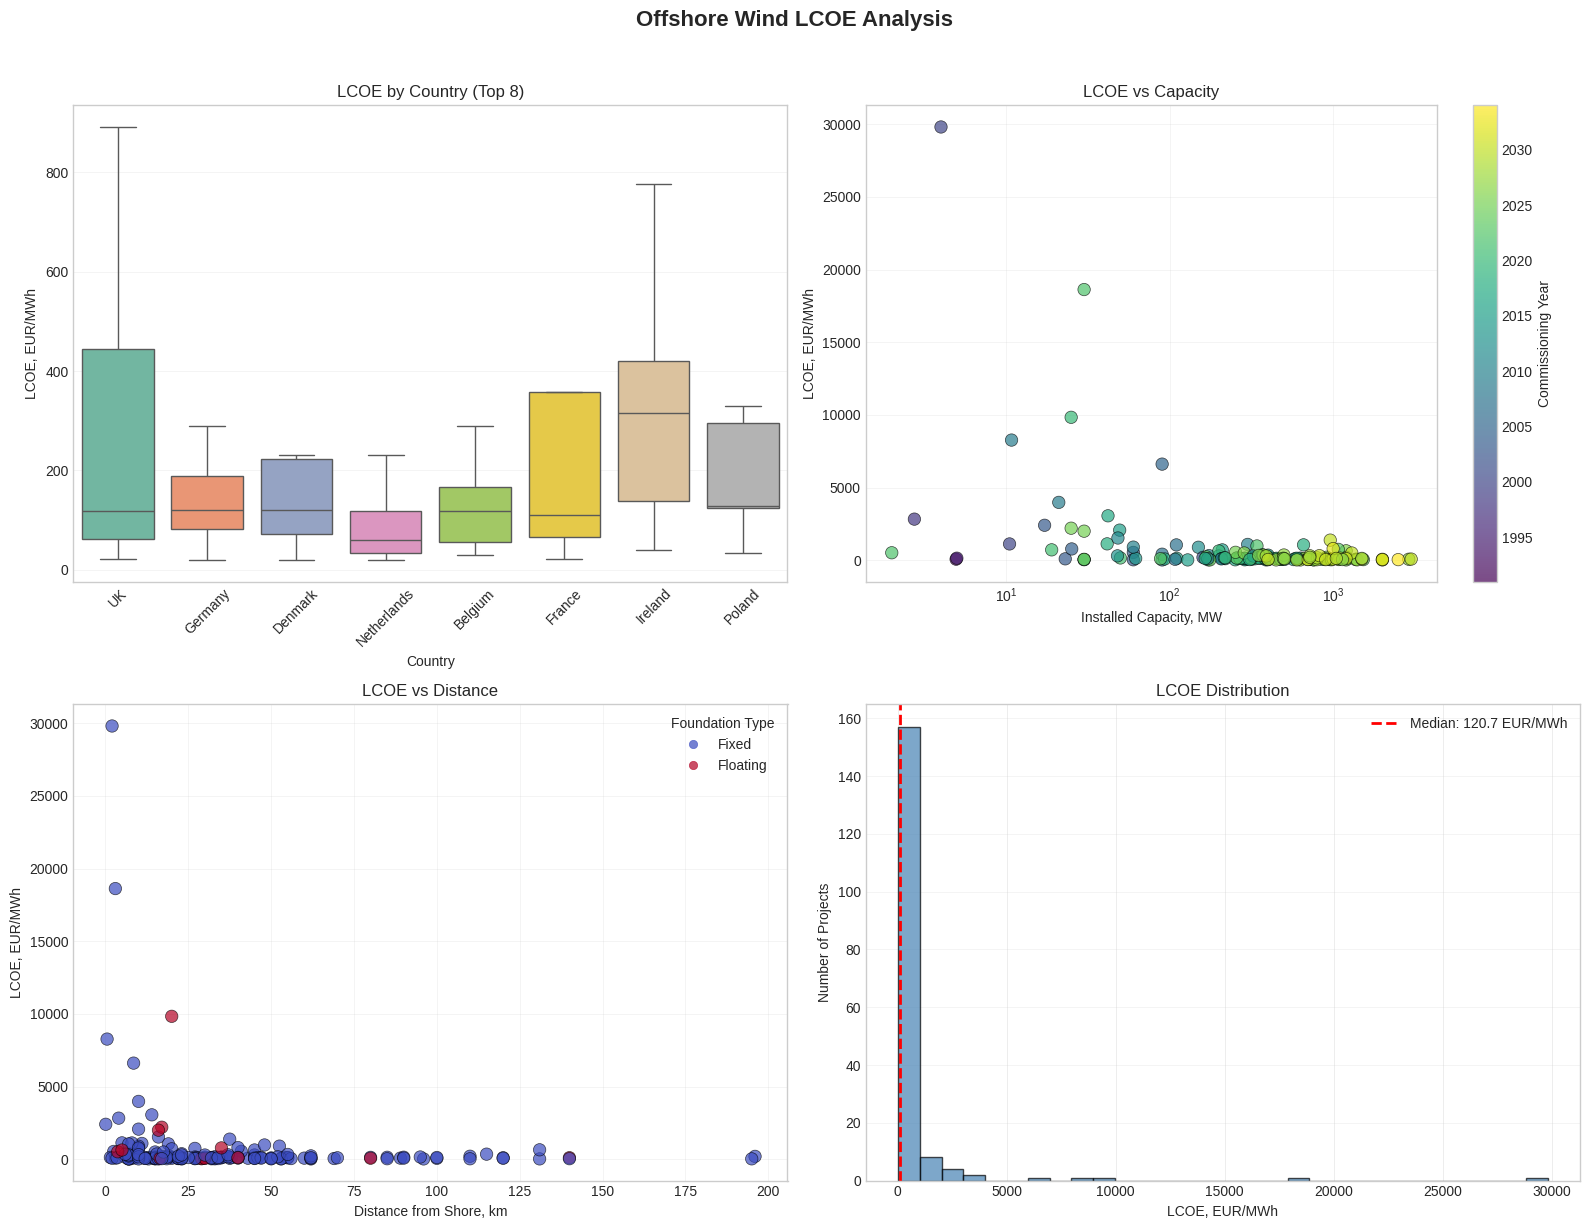

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Offshore Wind LCOE Analysis', fontsize=16, fontweight='bold', y=1.02)

top_countries = df_valid['country'].value_counts().head(8).index
df_top = df_valid[df_valid['country'].isin(top_countries)]

sns.boxplot(
    data=df_top,
    x='country',
    y='LCOE_EUR_per_MWh',
    ax=axes[0, 0],
    palette='Set2',
    showfliers=False
)
axes[0, 0].set_title('LCOE by Country (Top 8)')
axes[0, 0].set_xlabel('Country')
axes[0, 0].set_ylabel('LCOE, EUR/MWh')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)


scatter = axes[0, 1].scatter(
    df_valid['installed_capacity_MW'],
    df_valid['LCOE_EUR_per_MWh'],
    c=df_valid['commissioning_year'],
    cmap='viridis',
    s=80,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
axes[0, 1].set_xlabel('Installed Capacity, MW')
axes[0, 1].set_ylabel('LCOE, EUR/MWh')
axes[0, 1].set_title('LCOE vs Capacity')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=axes[0, 1])
cbar.set_label('Commissioning Year')


scatter2 = axes[1, 0].scatter(
    df_valid['distance_from_shore_km'],
    df_valid['LCOE_EUR_per_MWh'],
    c=df_valid['is_floating'].astype(int),
    cmap='coolwarm',
    s=80,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
axes[1, 0].set_xlabel('Distance from Shore, km')
axes[1, 0].set_ylabel('LCOE, EUR/MWh')
axes[1, 0].set_title('LCOE vs Distance')
axes[1, 0].grid(alpha=0.3)

handles, _ = scatter2.legend_elements()
axes[1, 0].legend(handles, ['Fixed', 'Floating'], title='Foundation Type')


axes[1, 1].hist(
    df_valid['LCOE_EUR_per_MWh'],
    bins=30,
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)
axes[1, 1].axvline(
    df_valid['LCOE_EUR_per_MWh'].median(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Median: {df_valid['LCOE_EUR_per_MWh'].median():.1f} EUR/MWh"
)
axes[1, 1].set_xlabel('LCOE, EUR/MWh')
axes[1, 1].set_ylabel('Number of Projects')
axes[1, 1].set_title('LCOE Distribution')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()


## 8. Validation

Reference LCOE ranges:

- Fixed-bottom (modern): 40–90 EUR/MWh  
- Floating: 80–150 EUR/MWh  
- Legacy (pre-2015): up to 120–200 EUR/MWh

In [14]:
def validate_lcoe(row: pd.Series) -> str:
    lcoe = row['LCOE_EUR_per_MWh']
    if pd.isna(lcoe):
        return 'No data'
    
    if row['is_floating']:
        low, high = 60, 200
    else:
        low, high = (50, 250) if row['commissioning_year'] < 2015 else (30, 120)
        
    if lcoe < low:
        return 'Below expected'
    elif lcoe > high:
        return 'Above expected (outlier)'
    else:
        return 'Valid'


df_valid['validation_status'] = df_valid.apply(validate_lcoe, axis=1)

print("Validation results:")
print(df_valid['validation_status'].value_counts())


outliers = df_valid[df_valid['validation_status'] == 'Above expected (outlier)']

if len(outliers) > 0:
    print(f"\nOutliers ({len(outliers)} projects):")
    display_cols = [
        'wind_farm_name', 'country', 'commissioning_year', 'installed_capacity_MW',
        'CAPEX_unit_EUR_per_MW', 'capacity_factor_est', 'LCOE_EUR_per_MWh'
    ]
    print(outliers[display_cols]
          .sort_values('LCOE_EUR_per_MWh', ascending=False)
          .to_string(index=False))


Validation results:
validation_status
Above expected (outlier)    80
Valid                       78
Below expected              18
Name: count, dtype: int64

Outliers (80 projects):
             wind_farm_name     country  commissioning_year  installed_capacity_MW  CAPEX_unit_EUR_per_MW  capacity_factor_est  LCOE_EUR_per_MWh
  Blyth Offshore (Original)          UK              2000.0                   4.00           1.339060e+09               0.4995      29809.700542
                  Beleolico       Italy              2022.0                  30.00           6.000000e+08               0.3075      18623.618238
         WindFloat Atlantic    Portugal              2020.0                  25.00           4.151058e+08               0.4035       9832.970412
              Avedore Holme     Denmark              2009.0                  10.80           3.490711e+08               0.4035       8266.856808
              Kentish Flats          UK              2005.0                  90.00           

## 9. Sensitivity Analysis (Tornado Diagram)

For the median project, analyze the impact of key parameters on LCOE:

- CAPEX ±10%  
- Wind speed ±0.5 m/s  
- Discount rate ±2%  
- OPEX ±10%  
- Lifetime ±5 years

Base project: Beatrice (UK)
Base LCOE: 121.0 EUR/MWh


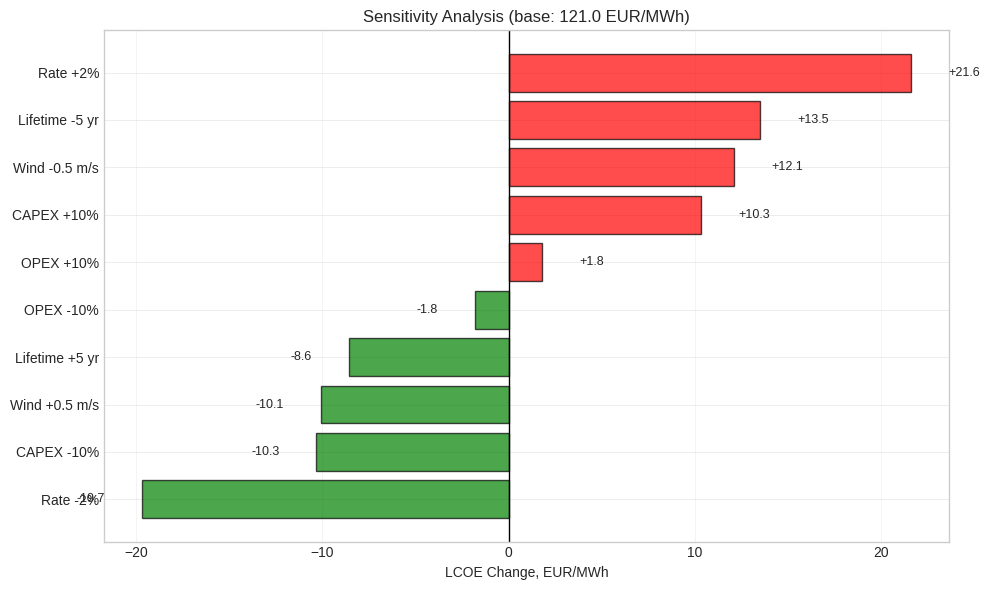

      Scenario  LCOE  Deviation
      Rate -2% 101.3      -19.7
    CAPEX -10% 110.7      -10.3
 Wind +0.5 m/s 110.9      -10.1
Lifetime +5 yr 112.4       -8.6
     OPEX -10% 119.2       -1.8
     OPEX +10% 122.8        1.8
    CAPEX +10% 131.3       10.3
 Wind -0.5 m/s 133.1       12.1
Lifetime -5 yr 134.5       13.5
      Rate +2% 142.6       21.6


In [15]:
median_project = df_valid.iloc[(df_valid['LCOE_EUR_per_MWh'] - df_valid['LCOE_EUR_per_MWh'].median()).abs().argsort()[:1]].iloc[0]

print(f"Base project: {median_project['wind_farm_name']} ({median_project['country']})")
print(f"Base LCOE: {median_project['LCOE_EUR_per_MWh']:.1f} EUR/MWh")

def calc_lcoe_sens(capex_mult, wind_delta, rate_delta, opex_mult, lifetime_delta):
    capex = median_project['CAPEX_total_EUR'] * capex_mult
    wind_new = median_project['mean_hub_wind_speed'] + wind_delta
    cf_new = np.clip(CF_SLOPE * wind_new + CF_INTERCEPT, 0.25, 0.65)
    production = 8760 * cf_new * 0.85 * median_project['installed_capacity_MW']
    r = DISCOUNT_RATE + rate_delta
    n = median_project['project_lifetime_years'] + lifetime_delta
    crf = r / (1 - (1 + r)**(-n))
    opex = median_project['annual_OPEX_total_EUR'] * opex_mult
    return (capex * crf + opex) / production

base_lcoe = median_project['LCOE_EUR_per_MWh']

scenarios = {
    'CAPEX +10%': calc_lcoe_sens(1.10, 0, 0, 1.0, 0),
    'CAPEX -10%': calc_lcoe_sens(0.90, 0, 0, 1.0, 0),
    'Wind +0.5 m/s': calc_lcoe_sens(1.0, 0.5, 0, 1.0, 0),
    'Wind -0.5 m/s': calc_lcoe_sens(1.0, -0.5, 0, 1.0, 0),
    'Rate +2%': calc_lcoe_sens(1.0, 0, 0.02, 1.0, 0),
    'Rate -2%': calc_lcoe_sens(1.0, 0, -0.02, 1.0, 0),
    'OPEX +10%': calc_lcoe_sens(1.0, 0, 0, 1.10, 0),
    'OPEX -10%': calc_lcoe_sens(1.0, 0, 0, 0.90, 0),
    'Lifetime +5 yr': calc_lcoe_sens(1.0, 0, 0, 1.0, 5),
    'Lifetime -5 yr': calc_lcoe_sens(1.0, 0, 0, 1.0, -5),
}

sens_df = pd.DataFrame({'Scenario': list(scenarios.keys()), 'LCOE': list(scenarios.values())})
sens_df['Deviation'] = sens_df['LCOE'] - base_lcoe
sens_df = sens_df.sort_values('Deviation')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x < 0 else 'red' for x in sens_df['Deviation']]
bars = ax.barh(sens_df['Scenario'], sens_df['Deviation'], color=colors, alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('LCOE Change, EUR/MWh')
ax.set_title(f'Sensitivity Analysis (base: {base_lcoe:.1f} EUR/MWh)')
ax.grid(True, alpha=0.3, axis='x')

for bar, dev in zip(bars, sens_df['Deviation']):
    ax.text(dev + (2 if dev > 0 else -2), bar.get_y() + bar.get_height()/2,
            f'{dev:+.1f}', ha='left' if dev > 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(sens_df[['Scenario','LCOE','Deviation']].round(1).to_string(index=False))


## 10. Project Map (Folium)

### LCOE Color Scale

- 🟢 < 60 EUR/MWh  
- 🟡 60–100 EUR/MWh  
- 🟠 100–150 EUR/MWh  
- 🔴 > 150 EUR/MWh

In [16]:
import folium
from folium.plugins import MarkerCluster

def lcoe_color(lc):
    if pd.isna(lc): return 'gray'
    elif lc < 60: return 'darkgreen'
    elif lc < 100: return 'orange'
    elif lc < 150: return 'red'
    else: return 'darkred'

m = folium.Map(location=[55.0, 5.0], zoom_start=4, tiles='CartoDB positron')
marker_cluster = MarkerCluster().add_to(m)

for _, row in df_valid.iterrows():
    if pd.isna(row['lat']) or pd.isna(row['lon']): continue
    color = lcoe_color(row['LCOE_EUR_per_MWh'])
    popup = (
        f"<b>{row['wind_farm_name']}</b><br>"
        f"Country: {row['country']}<br>"
        f"Capacity: {row['installed_capacity_MW']:.0f} MW<br>"
        f"Year: {row['commissioning_year']:.0f}<br>"
        f"LCOE: <b>{row['LCOE_EUR_per_MWh']:.1f}</b> EUR/MWh<br>"
        f"CAPEX: {(row['CAPEX_unit_EUR_per_MW']/1e6):.2f} million EUR/MW<br>"
        f"CF: {row['capacity_factor_est']:.3f}<br>"
        f"Type: {row['foundation_category']}")
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=6,
        popup=folium.Popup(popup, max_width=300),
        color=color, fill=True, fill_color=color, fill_opacity=0.7, weight=1
    ).add_to(marker_cluster)

legend_html = '''
<div style="position:fixed; bottom:50px; left:50px; width:180px; height:130px;
     background:white; border:2px solid grey; z-index:9999; font-size:12px;
     padding:10px; border-radius:5px;">
     <b>LCOE, EUR/MWh</b><br>
     <i style="background:darkgreen; width:12px; height:12px; display:inline-block;"></i> &lt; 60<br>
     <i style="background:orange; width:12px; height:12px; display:inline-block;"></i> 60–100<br>
     <i style="background:red; width:12px; height:12px; display:inline-block;"></i> 100–150<br>
     <i style="background:darkred; width:12px; height:12px; display:inline-block;"></i> &gt; 150<br>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

m.save('output/offshore_wind_lcoe_map.html')
print("Map saved: offshore_wind_lcoe_map.html")
m

Map saved: offshore_wind_lcoe_map.html


## 11. Results Export

In [17]:
output_cols = [
    'wind_farm_name', 'country', 'commissioning_year', 'installed_capacity_MW',
    'foundation_type', 'foundation_category', 'water_depth_m', 'distance_from_shore_km',
    'mean_hub_wind_speed', 'capacity_factor_est', 'capacity_factor_source',
    'grid_connection_model', 'project_lifetime_years',
    'CAPEX_total_EUR', 'CAPEX_unit_EUR_per_MW',
    'annual_production_MWh', 'OPEX_unit_kEUR_per_MW_year', 'annual_OPEX_total_EUR',
    'CRF', 'annual_CAPEX_EUR', 'LCOE_EUR_per_MWh', 'validation_status'
]

df_export = df_valid[output_cols].copy()
df_export.to_csv('output/offshore_wind_lcoe_results.csv', index=False)

print("Results saved: offshore_wind_lcoe_results.csv")
print(f"   Rows: {len(df_export)}, Columns: {len(output_cols)}")

summary = df_export.groupby('country').agg({
    'LCOE_EUR_per_MWh': ['mean','median','min','max','count'],
    'installed_capacity_MW': 'sum'
}).round(1)
summary.columns = ['LCOE_mean','LCOE_median','LCOE_min','LCOE_max','Projects','Total_MW']
print("\nLCOE summary by country:")
print(summary.sort_values('LCOE_median').to_string())


Results saved: offshore_wind_lcoe_results.csv
   Rows: 176, Columns: 22

LCOE summary by country:
             LCOE_mean  LCOE_median  LCOE_min  LCOE_max  Projects  Total_MW
country                                                                    
Greece            50.0         50.0      50.0      50.0         1     400.0
Norway            61.6         52.0      36.6     105.9         4    4618.0
Netherlands      108.1         60.8      20.5     713.8        19   18882.5
France           467.2        111.1      22.0    2202.6        13    7102.0
Belgium          143.3        117.6      30.0     378.3        10    4274.5
UK              1049.7        118.3      21.1   29809.7        48   27299.2
Denmark          922.7        119.4      19.8    8266.9        18    7880.0
Germany          237.7        121.2      20.6    1528.3        34   13216.5
Poland           176.4        127.6      34.6     329.5         9    8323.5
Ireland          320.8        314.8      40.0     775.8         7 

## 12. Project Classification

This section applies a five-level classification to offshore wind projects: **Bad**, **Below average**, **Average**, **Above average**, and **Good**. Lower LCOE values are rated better by percentile against the historic project dataset.


In [18]:
from src.lcoe import load_and_analyse

df_valid_classified = load_and_analyse(DATASET_PATH)
df_valid_classified[['wind_farm_name', 'LCOE_EUR_per_MWh', 'validation_status', 'classification']].head()


,wind_farm_name,LCOE_EUR_per_MWh,validation_status,classification
0,Hornsea 1,103.219769,Valid,Average
1,Hornsea 2,75.462735,Valid,Above average
2,Hornsea 3,66.147683,Valid,Above average
3,Dogger Bank A,22.955517,Below expected,Good
4,Dogger Bank B,648.603862,Above expected (outlier),Bad


### 13. Create and Classify a New Project

Use the following cell to enter parameters for a new offshore wind project. The script will prompt you for key values and classify the project as **Bad**, **Below average**, **Average**, **Above average**, or **Good**.


In [19]:
from src.lcoe import classify_new_project, classify_project_against_dataset, load_and_analyse
from wind_farm_classifier import build_report, find_nearest_or_none, print_report_table, save_report

def prompt_float(prompt):
    value = input(f'{prompt}: ')
    return float(value) if value.strip() else None

def prompt_int(prompt, default):
    value = input(f'{prompt} [{default}]: ')
    return int(value) if value.strip() else default

print('Enter new project data:')
print('Select grid connection model:')
print('  1 - developer provided')
print('  2 - TSO provided')
grid_choice = prompt_int('Enter number (1/2)', 1)
grid_map = {1: 'developer_provided', 2: 'TSO_provided'}
grid_model = grid_map.get(grid_choice, 'developer_provided')

print('Select foundation type:')
print('  1 - Fixed (monopile/jacket)')
print('  2 - Floating (semi-submersible etc.)')
foundation_choice = prompt_int('Enter number (1/2)', 1)
foundation_map = {1: 'Monopile', 2: 'Semi-submersible'}
foundation_type = foundation_map.get(foundation_choice, 'Monopile')

project_data = {
    'total_budget_EUR_2026': prompt_float('Total budget (EUR 2026)'),
    'installed_capacity_MW': prompt_float('Installed capacity (MW)'),
    'grid_connection_model': grid_model,
    'foundation_type': foundation_type,
    'distance_from_shore_km': prompt_float('Distance from shore (km)'),
    'mean_hub_wind_speed': prompt_float('Mean hub wind speed (m/s)'),
    'capacity_factor': prompt_float('Capacity factor'),
    'project_lifetime_years': prompt_float('Project lifetime years') or 25.0,
    'commissioning_year': prompt_int('Commissioning year', 2026),
    'lat': prompt_float('Latitude'),
    'lon': prompt_float('Longitude'),
}

df_valid = load_and_analyse(DATASET_PATH)
result = classify_new_project(project_data)
result['classification'] = classify_project_against_dataset(result, df_valid)
nearest = find_nearest_or_none(df_valid, project_data)
report = build_report(project_data, result, nearest)
save_report(report)
print_report_table(report)


Enter new project data:
Select grid connection model:
  1 - developer provided
  2 - TSO provided
Select foundation type:
  1 - Fixed (monopile/jacket)
  2 - Floating (semi-submersible etc.)


ValueError: could not convert string to float: '9,8'